**Environment Setup**

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/D100_Utility.py'
with open(utility_link) as f: exec(f.read())

**Necessary Parameter Setup**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
R_hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/D100_1000_500_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_hat_c_path)

R_hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/D100_1000_500_Rhat_n.pkl"
R_Hat_n_df = pd.read_pickle(R_hat_n_path)

In [ ]:
HighlightIndex = list(range(0, 100, 10)) + list(range(4, 100, 10))
Warmup_List = [10, 20, 30, 40,50, 100, 200, 500, 1000]

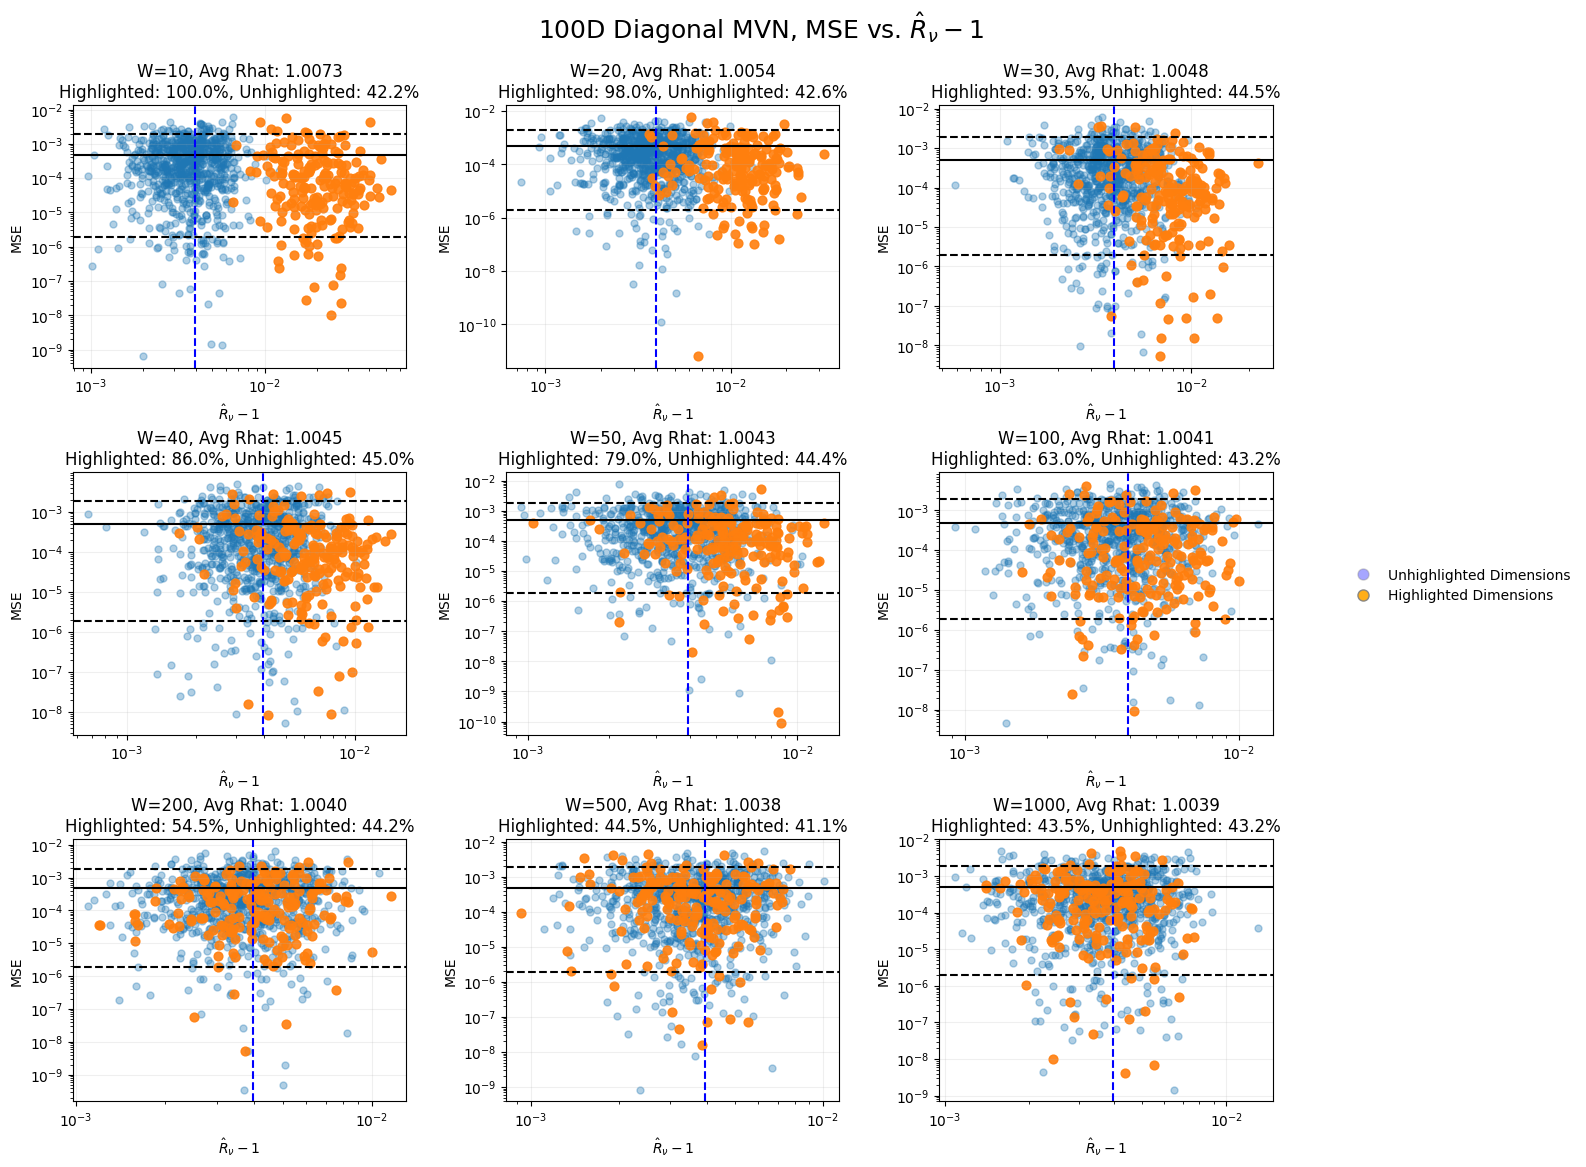

In [ ]:
plot_mse_vs_rhat_9("100D Diagonal MVN",
    R_Hat_c_df,
    Warmup_List,
    HighlightIndex,
    bound,
    threshold,
    num_chains_short)